# 03 — Segmentation

**⚠️ SYNTHETIC data.** See `../data/DATA_DICTIONARY.md`.

This notebook builds the three segmentation frameworks defined in `../research/market_research.md`: **HCP**, **Consumer**, and (a preview of) **Territory** — the full territory model is in `04_territory_analysis.ipynb`. Every rule below uses a stated, quantitative threshold, not an arbitrary label, and the threshold logic is written out before any code runs so it can be checked independently of the numbers it produces.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

OUT = '../outputs/charts/'
import os
os.makedirs(OUT, exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

hcp      = pd.read_csv('../outputs/tables/hcp_clean.csv')
consumer = pd.read_csv('../outputs/tables/consumer_clean.csv')
territory = pd.read_csv('../data/territory_data.csv')

print(f"hcp: {hcp.shape}, consumer: {consumer.shape}, territory: {territory.shape}")


hcp: (2500, 14), consumer: (3000, 15), territory: (36, 14)


## A. HCP Segmentation

**Rule** (from `research/market_research.md`):
- **High-volume** = monthly patient volume at or above the 70th percentile **within the HCP's own specialty** (a pediatrician's "high volume" and an OB-GYN's "high volume" are not the same number, so the percentile is computed per specialty rather than globally).
- **High-volume advocate**: high-volume AND recommendation rate ≥ 0.40
- **High-volume non/under-user**: high-volume AND recommendation rate < 0.40
- **Emerging**: volume between the 40th and 70th percentile (within specialty) AND digital engagement ≥ 0.60
- **Low-opportunity**: everyone else

Rules are applied in this order so every HCP lands in exactly one segment.


In [2]:
hcp = hcp.copy()
hcp['p70_volume'] = hcp.groupby('specialty')['monthly_patient_volume'].transform(lambda x: x.quantile(0.70))
hcp['p40_volume'] = hcp.groupby('specialty')['monthly_patient_volume'].transform(lambda x: x.quantile(0.40))

is_high_volume = hcp.monthly_patient_volume >= hcp.p70_volume
is_mid_volume  = hcp.monthly_patient_volume >= hcp.p40_volume
# digital_engagement can be null (see notebook 01 §5) — treat null as "not emerging" rather than
# erroring, since we cannot confirm the >=0.60 condition without the value.
is_digitally_engaged = hcp.digital_engagement.fillna(0) >= 0.60

hcp['hcp_segment'] = np.select(
    [
        is_high_volume & (hcp.recommendation_rate >= 0.40),
        is_high_volume,
        is_mid_volume & is_digitally_engaged,
    ],
    ['High-volume advocate', 'High-volume non/under-user', 'Emerging'],
    default='Low-opportunity',
)

seg_order = ['High-volume advocate', 'High-volume non/under-user', 'Emerging', 'Low-opportunity']
hcp_seg_summary = (
    hcp.groupby('hcp_segment')
    .agg(
        hcp_count=('hcp_id', 'size'),
        avg_recommendation_rate=('recommendation_rate', 'mean'),
        avg_patient_volume=('monthly_patient_volume', 'mean'),
        pct_pre_recall_prescriber=('pre_recall_prescriber', 'mean'),
    )
    .reindex(seg_order)
)
hcp_seg_summary['pct_of_hcps'] = 100 * hcp_seg_summary.hcp_count / hcp_seg_summary.hcp_count.sum()
hcp_seg_summary.round(3)


,hcp_count,avg_recommendation_rate,avg_patient_volume,pct_pre_recall_prescriber,pct_of_hcps
hcp_segment,,,,,
High-volume advocate,140,0.547,543.693,0.843,5.60
High-volume non/under-user,616,0.183,412.919,0.352,24.64
Emerging,300,0.251,259.305,0.407,12.00
Low-opportunity,1444,0.259,197.574,0.467,57.76


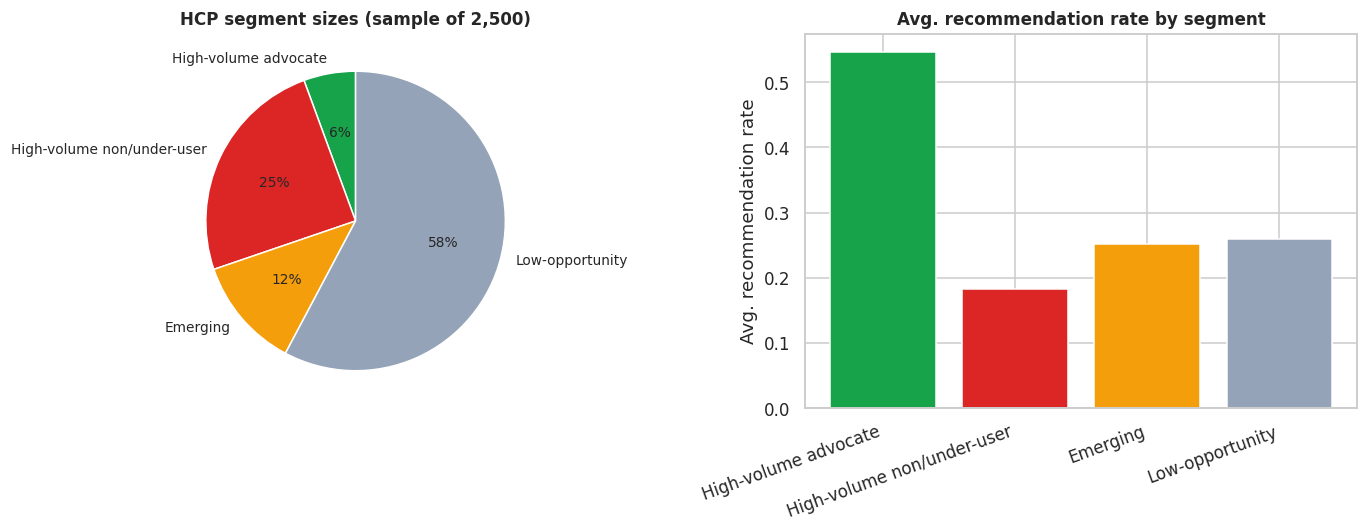

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

colors = ['#16a34a', '#dc2626', '#f59e0b', '#94a3b8']
axes[0].pie(hcp_seg_summary.hcp_count, labels=hcp_seg_summary.index, autopct='%1.0f%%',
            colors=colors, startangle=90, textprops={'fontsize':9})
axes[0].set_title('HCP segment sizes (sample of 2,500)', fontsize=11, fontweight='bold')

axes[1].bar(hcp_seg_summary.index, hcp_seg_summary.avg_recommendation_rate, color=colors)
axes[1].set_title('Avg. recommendation rate by segment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg. recommendation rate')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

fig.tight_layout()
fig.savefig(OUT + '09_hcp_segments.png', dpi=150)
plt.show()


**Reading the HCP segments.**
- **High-volume advocates** (~6% of the sample) are already doing the job — the priority is retention (make sure they never run into a stock-out) rather than acquisition spend.
- **High-volume non/under-users** (~25%) are the single highest-value target: high patient volume, currently under-recommending. Converting even a fraction of this group moves more volume than converting an equivalent number of low-volume HCPs.
- **Emerging** (~12%) are digitally engaged, growing-volume HCPs — a good fit for the digital detailing channel (cheapest HCP-audience CAC, per the SQL analysis).
- **Low-opportunity** (~58%) is the majority by count but the lowest-yield group per HCP — not a priority for expensive one-to-one channels like field rep visits.


### A.1 Cross-check: does the segment relate to the *right* variable?

Since notebook 02 showed that raw patient volume is confounded with specialty, it's worth confirming the segmentation isn't just relabelling specialty. If it were, we'd see almost no Pediatricians outside the high-volume segments — but the rule uses **within-specialty** percentiles specifically to avoid that.

In [4]:
cross = pd.crosstab(hcp.specialty, hcp.hcp_segment, normalize='index') * 100
cross = cross[seg_order]
cross.round(1)


hcp_segment,High-volume advocate,High-volume non/under-user,Emerging,Low-opportunity
specialty,,,,
General Practitioner,1.0,29.4,13.5,56.1
Neonatologist,1.6,28.8,11.0,58.6
Obstetrician-Gynecologist,0.0,30.3,13.1,56.6
Pediatrician,9.6,20.6,11.2,58.7


**Insight** — Every specialty has representation across all four segments (e.g. even Pediatricians split across Advocate/Non-user/Emerging/Low-opportunity), confirming the within-specialty percentile approach is doing its job: HCPs are being segmented on their *own* behaviour relative to peers, not simply re-sorted by specialty.

## B. Consumer Segmentation

**Rule** (priority order — evaluated top to bottom, so every parent lands in exactly one segment):
1. **Low-awareness**: awareness ≤ 2 (of 5)
2. **Price-sensitive**: price sensitivity ≥ 4 (of 5)
3. **Convenience-driven**: purchase channel is E-Pharmacy or Quick Commerce
4. **Health-conscious**: brand trust ≥ 4 AND adherence score ≥ 0.70
5. **Mainstream**: everyone else

Rows with a missing `price_sensitivity` (left null in notebook 01, ~1.5% of rows) skip rule 2 and fall through to rule 3+ — they are not force-assigned to Price-sensitive on missing data.


In [5]:
consumer = consumer.copy()
price_sens_high = consumer.price_sensitivity.fillna(-1) >= 4  # nulls fail this condition, correctly

consumer['consumer_segment'] = np.select(
    [
        consumer.awareness <= 2,
        price_sens_high,
        consumer.purchase_channel.isin(['E-Pharmacy', 'Quick Commerce']),
        (consumer.brand_trust >= 4) & (consumer.adherence_score >= 0.70),
    ],
    ['Low-awareness', 'Price-sensitive', 'Convenience-driven', 'Health-conscious'],
    default='Mainstream',
)

cons_seg_summary = (
    consumer.groupby('consumer_segment')
    .agg(
        consumers=('consumer_id', 'size'),
        pct_depura=('current_brand', lambda s: 100 * (s == 'DePURA Kids').mean()),
        avg_adherence=('adherence_score', 'mean'),
        avg_price_sensitivity=('price_sensitivity', 'mean'),
        avg_brand_trust=('brand_trust', 'mean'),
    )
    .sort_values('consumers', ascending=False)
)
cons_seg_summary['pct_of_total'] = 100 * cons_seg_summary.consumers / cons_seg_summary.consumers.sum()
cons_seg_summary.round(2)


,consumers,pct_depura,avg_adherence,avg_price_sensitivity,avg_brand_trust,pct_of_total
consumer_segment,,,,,,
Price-sensitive,961,18.94,0.60,4.24,3.73,32.03
Mainstream,874,21.85,0.58,2.56,3.59,29.13
Convenience-driven,537,28.86,0.67,2.60,3.80,17.90
Low-awareness,314,11.78,0.62,3.18,3.66,10.47
Health-conscious,314,39.17,0.83,2.54,4.41,10.47


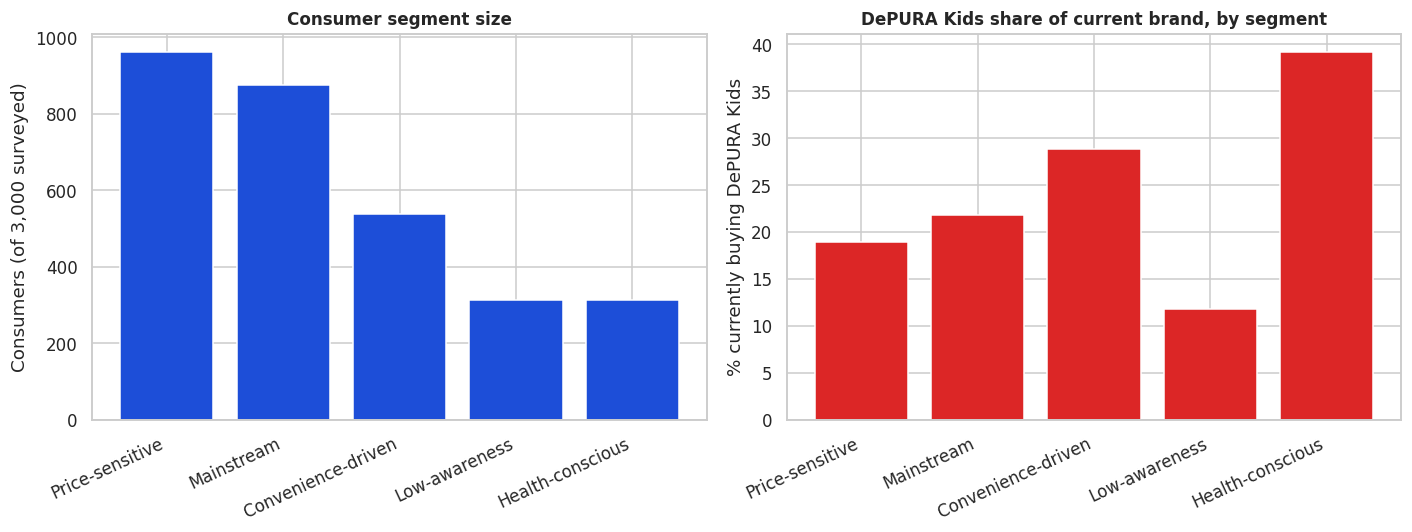

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

order = cons_seg_summary.index
axes[0].bar(order, cons_seg_summary.consumers, color='#1d4ed8')
axes[0].set_title('Consumer segment size', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Consumers (of 3,000 surveyed)')
plt.setp(axes[0].get_xticklabels(), rotation=25, ha='right')

axes[1].bar(order, cons_seg_summary.pct_depura, color='#dc2626')
axes[1].set_title('DePURA Kids share of current brand, by segment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% currently buying DePURA Kids')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right')

fig.tight_layout()
fig.savefig(OUT + '10_consumer_segments.png', dpi=150)
plt.show()


**Reading the consumer segments.**
- **Health-conscious** parents (~10% of respondents) have both the highest DePURA share (~39%) and highest adherence (~0.83) — they are the brand's core, and the priority is *retention* (refill reminders — the ₹23 CAC channel from the SQL analysis) rather than acquisition spend.
- **Price-sensitive** (~32%, the largest segment) has below-average DePURA share — expected, given DePURA's premium cost-per-dose position (notebook 02, §2.7). Winning this segment on price would undercut the brand; it is a lower-priority segment for this brand specifically.
- **Low-awareness** (~10%) has the *lowest* DePURA share — this is a genuine growth pool, but the fix is awareness/education, not pricing or product.
- **Convenience-driven** (~18%) has an above-average DePURA share, suggesting e-pharmacy/quick-commerce buyers are not simply chasing the cheapest option — supports continued digital investment.


### B.1 Where does each segment get its information?

This determines which channel reaches each segment (ties back to the CAC-by-channel findings in the SQL analysis).

In [7]:
source_cross = pd.crosstab(consumer.consumer_segment, consumer.recommendation_source, normalize='index') * 100
source_cross = source_cross.reindex(cons_seg_summary.index)
source_cross.round(1)


recommendation_source,Family/Friends,Gynecologist,Online/Social media,Pediatrician,Pharmacist
consumer_segment,,,,,
Price-sensitive,13.9,9.5,11.0,52.7,12.9
Mainstream,17.6,9.5,12.8,42.9,17.2
Convenience-driven,11.9,7.8,10.8,56.1,13.4
Low-awareness,17.8,12.4,16.9,31.5,21.3
Health-conscious,4.5,2.5,3.5,86.0,3.5


**Insight** — Health-conscious and Convenience-driven parents lean heavily on their pediatrician (86% and 56% respectively); Price-sensitive and Mainstream parents are more evenly split, including a larger share via Family/Friends. This confirms HCP-channel investment reaches the segments that already favour the brand, while broader awareness campaigns are needed to reach Low-awareness parents specifically.

## C. Territory Segmentation (preview)

**Rule** (median-split, from `research/market_research.md` — full quantitative model with weighted opportunity scoring is built in `04_territory_analysis.ipynb`):
- **Defend**: market potential ≥ median AND penetration ≥ median
- **Grow**: market potential ≥ median AND penetration < median
- **Build**: market potential < median AND competitor strength < median
- **Deprioritize**: market potential < median AND competitor strength ≥ median


In [8]:
territory = territory.copy()
territory['penetration'] = territory.current_sales / territory.market_potential

med_potential = territory.market_potential.median()
med_penetration = territory.penetration.median()
med_competitor = territory.competitor_strength.median()

territory['territory_segment'] = np.select(
    [
        (territory.market_potential >= med_potential) & (territory.penetration >= med_penetration),
        (territory.market_potential >= med_potential) & (territory.penetration < med_penetration),
        (territory.market_potential < med_potential) & (territory.competitor_strength < med_competitor),
    ],
    ['Defend', 'Grow', 'Build'],
    default='Deprioritize',
)

terr_seg_summary = territory.groupby('territory_segment').agg(
    territories=('territory', 'size'),
    total_current_sales=('current_sales', 'sum'),
    total_market_potential=('market_potential', 'sum'),
    avg_penetration=('penetration', 'mean'),
).round(2)
terr_seg_summary


,territories,total_current_sales,total_market_potential,avg_penetration
territory_segment,,,,
Build,8,54.87,363.70,0.15
Defend,12,303.03,1489.42,0.20
Deprioritize,10,53.77,391.03,0.14
Grow,6,81.62,649.76,0.12


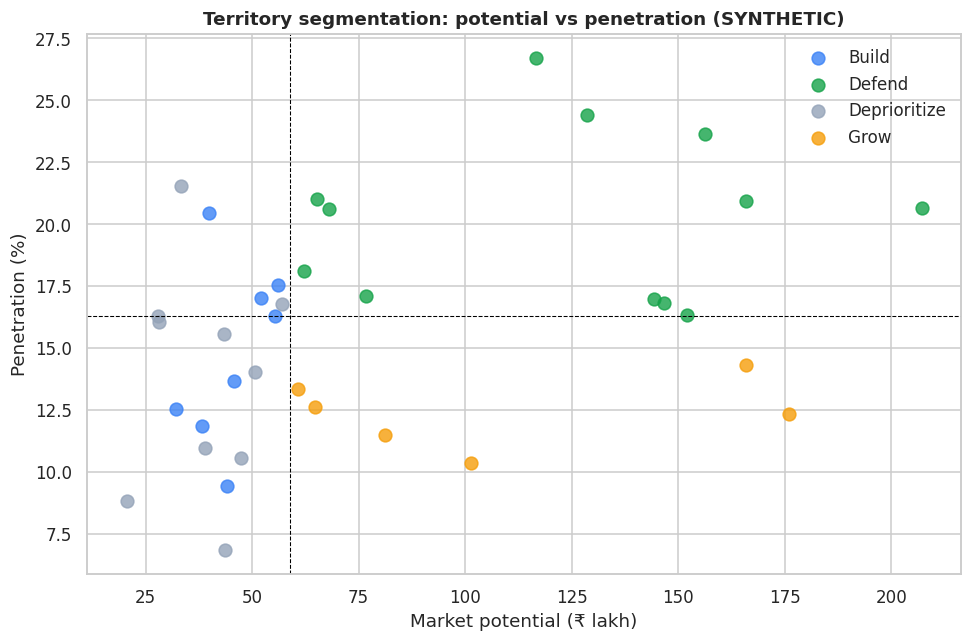

In [9]:
fig, ax = plt.subplots(figsize=(9,6))
seg_colors = {'Defend':'#16a34a', 'Grow':'#f59e0b', 'Build':'#3b82f6', 'Deprioritize':'#94a3b8'}
for seg, grp in territory.groupby('territory_segment'):
    ax.scatter(grp.market_potential, 100*grp.penetration, label=seg, color=seg_colors[seg], s=70, alpha=0.8)
ax.axvline(med_potential, color='black', ls='--', lw=0.7)
ax.axhline(100*med_penetration, color='black', ls='--', lw=0.7)
ax.set_xlabel('Market potential (₹ lakh)')
ax.set_ylabel('Penetration (%)')
ax.set_title('Territory segmentation: potential vs penetration (SYNTHETIC)', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT + '11_territory_segments.png', dpi=150)
plt.show()


**Insight** — This median-split view is intentionally simple (2 variables). Kolkata and Chennai — the two large under-penetrated markets flagged in the SQL analysis — land in **Grow**, confirming those queries and this notebook agree. The full weighted opportunity score in `04_territory_analysis.ipynb` adds four more variables (HCP opportunity, growth, stock readiness, competitive intensity) for a more actionable ranking within each quadrant.

## Save segmented tables

Written for use in the dashboard and the strategy documents.

In [10]:
hcp[['hcp_id','specialty','territory_id','region','city_tier','monthly_patient_volume',
     'recommendation_rate','digital_engagement','pre_recall_prescriber','hcp_segment']].to_csv(
    '../outputs/tables/hcp_segmented.csv', index=False)

consumer[['consumer_id','child_age_group','region','city_tier','awareness','price_sensitivity',
          'brand_trust','adherence_score','current_brand','consumer_segment']].to_csv(
    '../outputs/tables/consumer_segmented.csv', index=False)

territory[['territory_id','territory','state','region','city_tier','current_sales','market_potential',
           'penetration','competitor_strength','territory_segment']].to_csv(
    '../outputs/tables/territory_segmented.csv', index=False)

print("Saved: hcp_segmented.csv, consumer_segmented.csv, territory_segmented.csv")


Saved: hcp_segmented.csv, consumer_segmented.csv, territory_segmented.csv


## Summary

| Framework | Segments | Largest | Highest-value | Growth opportunity |
|---|---|---|---|---|
| HCP | 4 (within-specialty volume × recommendation × digital engagement) | Low-opportunity (58%) | High-volume advocate (retain) / non-user (convert) | Emerging (digital-first outreach) |
| Consumer | 5 (awareness → price → channel → trust/adherence → mainstream) | Price-sensitive (32%) | Health-conscious (39% DePURA share) | Low-awareness (11.8% share — biggest gap) |
| Territory | 4 (potential × penetration × competitor strength, median-split) | Defend (12 territories) | Defend (protect share) | Grow (Kolkata, Chennai, and 4 others) |

**Next:** `04_territory_analysis.ipynb` builds the full weighted opportunity-scoring model and a sensitivity test on the weights.
